In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Checkerboard_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding
from torch.utils.data import DataLoader

In [29]:
n_rows = 4
batch_size = 10000

checkerboard_dataset = Checkerboard_Dataset(n_rows, dataset_size=100000)


loader = DataLoader(checkerboard_dataset, batch_size=batch_size, shuffle = True)
batch = next(iter(loader))
# first_sample = batch[0]
print("sample shape of checkerboard dataset", batch.shape)

sample shape of checkerboard dataset torch.Size([10000, 2])


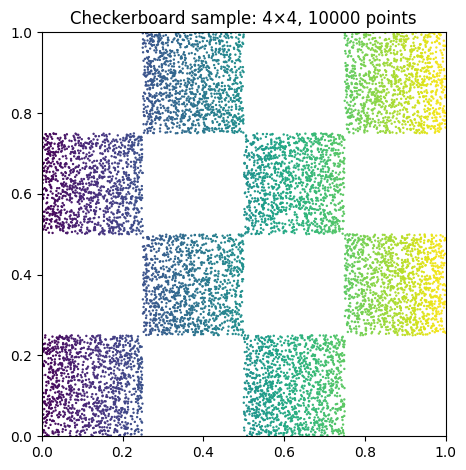

In [30]:
fig,ax = plt.subplots()
ax.scatter(batch[:,0],batch[:,1],s = 0.5, c= batch[:,0], cmap = "viridis")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title(f"Checkerboard sample: {n_rows}×{n_rows}, {batch_size} points")
plt.tight_layout()
plt.show()

torch.Size([10000, 2])
torch.Size([10000, 3])


Text(0.5, 0.92, 'Checkerboard on 2d torus')

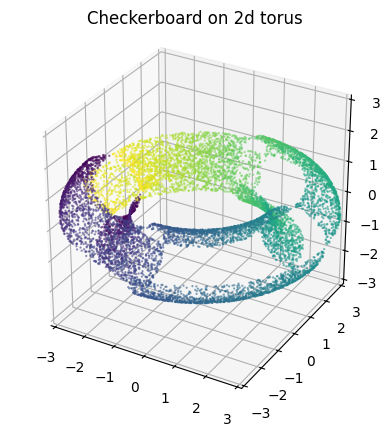

In [31]:
# Lie torus data like checkerboard
Torus_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(Torus_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))
print(batched_sample.shape)
theta1 = batched_sample[:,0]
theta2 = batched_sample[:,1]
# using 3d torus embedding to plot the checkerboard
torusEmbedding = torus_embedding(theta1,theta2)
print(torusEmbedding.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(torusEmbedding[:,0],torusEmbedding[:,1],torusEmbedding[:,2],c=theta1,cmap = "viridis", s = 0.5, alpha = 0.5)
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_zlim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on 2d torus")

Text(0.5, 1.0, 'Checkerboard on -pi, pi coordinate')

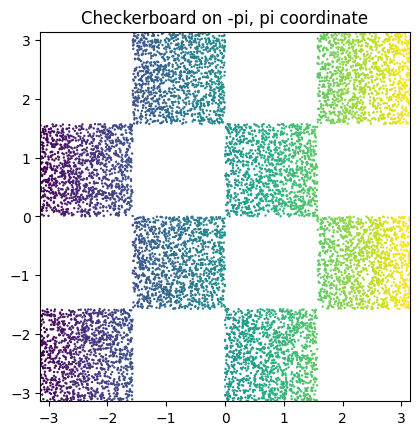

In [32]:
# plot checker board on the -pi, pi coordinate
fig,ax = plt.subplots()
ax.scatter(theta1,theta2,s = 0.5, c=theta1, cmap = "viridis")
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on -pi, pi coordinate")

## Sample Forward of checkerboard dataset from TDM diffusion model.

torch.Size([10000, 2])
shape of each batch torch.Size([10000, 2])


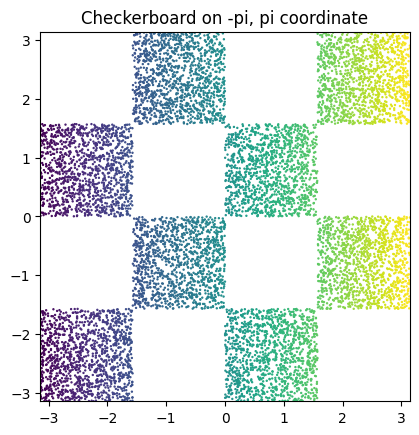

In [33]:
import src.diffusion as diffusion
import src.sde as sde

model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler", simplified_param=False)
dataset_size = 100000
batch_size = 10000
checkerboard_dataset = Checkerboard_Dataset(n_rows, dataset_size=dataset_size)
matrix_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(matrix_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))

fig,ax = plt.subplots()
ax.scatter(batched_sample[:,0],batched_sample[:,1],s = 0.5, c=batched_sample[:,0], cmap = "viridis")
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on -pi, pi coordinate")




print(batched_sample.shape)
theta1 = batched_sample[:,0]
theta2 = batched_sample[:,1]
print("shape of each batch",batched_sample.shape)
# Fixed times on the forward process
constant_t_forward = (0.01, 0.4, 0.7, 1.0, 15.0)
unconditional_samples = []
scores = []
# sample the forward process at fixed times
for i in range(len(constant_t_forward)):
    unconditional_sample_i, score_i = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = constant_t_forward[i])
    unconditional_samples.append(unconditional_sample_i)
    scores.append(score_i)
# shape: unconditional_samples: (constant_t_forward, batch_size, 2)
# shape: scores: (constant_t_forward, batch_size, 2)

shape of vts torch.Size([10000, 2])
shape of fts torch.Size([10000, 2])
shape of score torch.Size([10000, 2])
shape of fts of the first sample torch.Size([10000, 2])
shape of vts of the first sample torch.Size([10000, 2])
max of noised theta1 of the first sample tensor(3.1407)
min of noised theta1 of the first sample tensor(-3.1403)


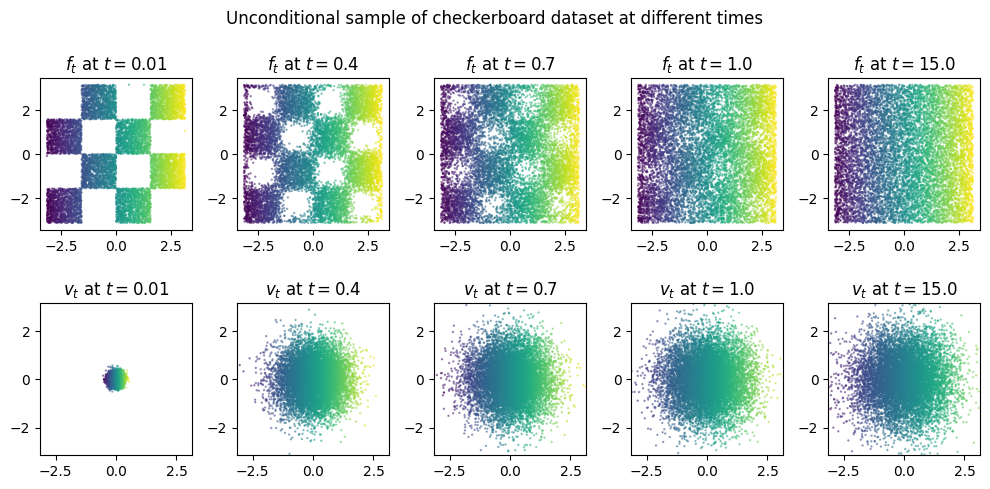

In [34]:
# extract the first sample of the unconditional samples
# post-process the unconditional samples to get the noised theta1 and theta2
fts_list = []
vts_list = []
theta1_noise_list = []
theta2_noise_list = []
scores_list = []
for ti in range(len(constant_t_forward)):
    vts_ti = unconditional_samples[ti][0]
    fts_ti = unconditional_samples[ti][1]
    scores_ti = scores[ti]
    theta1_noise_ti = fts_ti[:,0]
    theta2_noise_ti = fts_ti[:,1]
    fts_list.append(fts_ti)
    vts_list.append(vts_ti)
    theta1_noise_list.append(theta1_noise_ti)
    theta2_noise_list.append(theta2_noise_ti)
    scores_list.append(scores_ti)
    if ti == 0:
        print("shape of vts",vts_ti.shape)
        print("shape of fts",fts_ti.shape)
        print("shape of score",scores_ti.shape)
        print("shape of fts of the first sample",fts_ti.shape)
        print("shape of vts of the first sample",vts_ti.shape)
        # check the max and min of fts
        print("max of noised theta1 of the first sample",fts_ti[:,0].max())
        print("min of noised theta1 of the first sample",fts_ti[:,0].min())

# plot the unconditional sample for each constant t
fig,ax = plt.subplots(2,len(constant_t_forward),figsize=(10,5))
for i in range(len(constant_t_forward)):
    
    # plot the unconditional sample
    ax[0][i].scatter(theta1_noise_list[i],theta2_noise_list[i],c=theta1_noise_list[i],cmap = "viridis",s = 0.5,alpha = 0.5)
    # ax.set_xlim(-np.pi,np.pi)
    # ax.set_ylim(-np.pi,np.pi)
    ax[0][i].set_aspect("equal")
    ax[0][i].set_title("$f_t$ at $t=" + str(constant_t_forward[i]) + "$")
    ax[1][i].scatter(vts_list[i][:,0],vts_list[i][:,1],c=vts_list[i][:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
    ax[1][i].set_aspect("equal")
    ax[1][i].set_xlim(-np.pi,np.pi)
    ax[1][i].set_ylim(-np.pi,np.pi)
    ax[1][i].set_title("$v_t$ at $t=" + str(constant_t_forward[i]) + "$")
fig.suptitle("Unconditional sample of checkerboard dataset at different times") 
plt.tight_layout()
plt.show()

## Check the score of the forward process at exact time t

tensor(3.0142)
tensor(-2.7207)


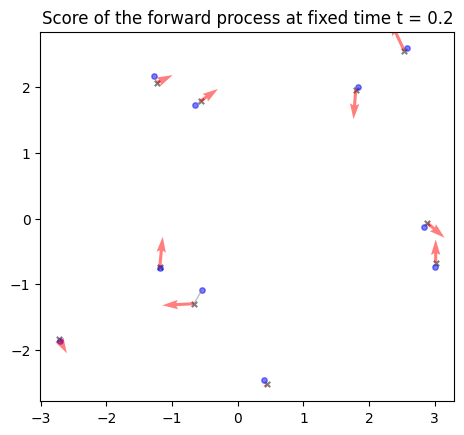

In [35]:
from matplotlib.collections import LineCollection
# Test on the smaller dataset
batch_size = 10
checkerboard_dataset = Checkerboard_Dataset(n_rows)
Lie_dataset = TorusLieWrapper(checkerboard_dataset)
Angle_dataset = AngleTorusWrapper(Lie_dataset)
data_loader_small = DataLoader(Angle_dataset, batch_size=batch_size, shuffle = True)

batched_sample = next(iter(data_loader_small))

fixed_t = 0.2
# sample the forward process at fixed time
model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler", simplified_param=True)
unconditional_sample, score_batched = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = fixed_t)

f0s_batched = batched_sample

vts_batched = unconditional_sample[0]
fts_batched = unconditional_sample[1]
theta1_noise_1st = fts_batched[:,0]
theta2_noise_1st = fts_batched[:,1]
print(max(theta1_noise_1st))
print(min(theta1_noise_1st))
# plot the score of the forward process at fixed time
f0_pts = f0s_batched.reshape(-1,2).numpy()
fts_pts = fts_batched.reshape(-1,2).numpy()

segments = np.stack([f0_pts,fts_pts],axis = 1)

fig,ax = plt.subplots()
ax.scatter(fts_batched[:,0],fts_batched[:,1],c="black",s = 15,alpha = 0.5, marker = "x")
ax.scatter(f0s_batched[:,0],f0s_batched[:,1],c="blue",s = 15,alpha = 0.5, marker = "o")
# connect points in fts_batched and f0s_batched
lc = LineCollection(segments, colors="gray", alpha=0.5,linewidths=1)
ax.add_collection(lc)
ax.quiver(theta1_noise_1st,theta2_noise_1st,score_batched[:,0],score_batched[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Score of the forward process at fixed time t = " + str(fixed_t))
plt.show()










tensor([[-1.5980,  0.0300]])
tensor([[1.1991]])
test velocity and position: tensor([[-0.4602,  1.3489]]) tensor([[-1.7910,  0.7211]])
predicted score campares to score ground truth: tensor([[ 0.1116, -0.0169]], grad_fn=<AddmmBackward0>) tensor([[ 0.5630, -1.5183]])
tensor([[ 2.2338,  2.1423],
        [ 0.7304, -2.1713],
        [-0.0779,  2.0704]], grad_fn=<Atan2Backward0>)
tensor([[-1.5980,  0.0300]])
tensor([[-0.3972,  0.3034],
        [-0.2061, -0.1280],
        [ 0.1498, -0.2831]], grad_fn=<AddBackward0>)
torch.Size([3, 2])


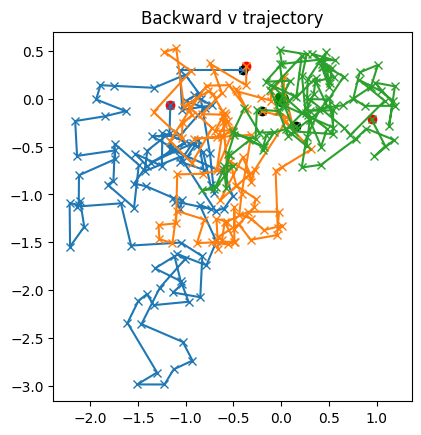

In [36]:
# Load the trained model


from src.diffusion import TDMDiffusion
from src.scoreNN import TDM_SimpleScoreMLP

device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"
batch_size = 512
n_epoch = 50
lr = 1e-3
total_time = 2.0
# data shape: each sample -> (dim,)
dim = 2
# model
x_lifting_dim = 64
time_embedding_half_dim = 32  # must be even
time_embedding_scale = 1.0
position_fourier_bands = 8
t_dist_kw = "quadratic"
use_weighted_loss = True
hidden_dim = [512,512]
output_dim = dim
model = TDMDiffusion(dim=dim, integrator_type="Euler", simplified_param=True).to(device)
score_nn = TDM_SimpleScoreMLP(
    dim=dim,
    x_lifting_dim=x_lifting_dim,
    time_embedding_half_dim=time_embedding_half_dim,
    time_embedding_scale=time_embedding_scale,
    position_fourier_bands=position_fourier_bands,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    with_sincos_position=True,
    only_sincos_position=True
).to(device)
state_dict = torch.load("simple_score_mlp_checkerboard.pt", map_location="cpu")
score_nn.load_state_dict(state_dict)

# Plot the learned score and real score given one point and time

# sample one point and time in [-pi, pi] x [-pi, pi]
test_point = torch.rand(size=(1,2)) * 2 * np.pi - np.pi
test_time = torch.rand(size=(1,1)) * 2
test_v0 = torch.zeros(size=(1,2))

print(test_point)
print(test_time)

# get the real score
latents, real_score = model.sample_forward(f0 = test_point, total_time = 2.0, t_dist_kw = "constant", constant_t = test_time)
vt = latents[0]
ft = latents[1]

print("test velocity and position:", vt,ft)


# get the predicted score
pred_score = score_nn(ft, vt, test_time)

real_score = (1- torch.exp(-test_time))/(1 + torch.exp(-test_time)) * real_score - vt/ (model.sde.sigma_t(test_time)**2)

pred_f_traj, pred_v_traj, t_list = model.sample_backward(fT_prior_kw="uniform", vT_prior_kw="stdGauss", data_shape=(3, 2), total_time=2.0, tdm_score_fn=score_nn, sample_trajectory=True)

print("predicted score campares to score ground truth:", pred_score, real_score)

print(pred_f_traj[-1])
print(test_point)
print(pred_v_traj[-3])
print(pred_v_traj[0].shape)



# plot the backward v trajectory
pred_v_traj_cpu = [v.detach().cpu() for v in pred_v_traj]
pred_vx_traj_cpu = [v[:,0].squeeze() for v in pred_v_traj_cpu]
pred_vy_traj_cpu = [v[:,1].squeeze() for v in pred_v_traj_cpu]

pred_vx_traj_cpu = pred_vx_traj_cpu[:-2]
pred_vy_traj_cpu = pred_vy_traj_cpu[:-2]
fig,ax = plt.subplots()
ax.plot(pred_vx_traj_cpu,pred_vy_traj_cpu, marker = "x")
ax.scatter(pred_vx_traj_cpu[0],pred_vy_traj_cpu[0], marker = "o",c = "red")
ax.scatter(pred_vx_traj_cpu[-1],pred_vy_traj_cpu[-1], marker = "o",c = "black")
ax.scatter(0,0, marker = "o",c = "green",s = 100)
ax.set_aspect("equal")
ax.set_title("Backward v trajectory")
plt.show()


# recoverd f0, real f0 and predicted score at ft, real score at ft




## Visualize Learned score field, both total score and velocities score

torch.Size([10000, 2])
torch.Size([1, 2])
torch.Size([10000, 2])
tensor([[ 0.2397, -0.0548],
        [ 0.2466, -0.0760],
        [ 0.2343, -0.0909],
        ...,
        [ 0.1616,  0.0201],
        [ 0.2081, -0.0236],
        [ 0.2397, -0.0548]], grad_fn=<AddmmBackward0>)
tensor([0.2083, 0.2282, 0.2300,  ..., 0.1000, 0.1639, 0.2083],
       grad_fn=<StdBackward0>) tensor([0.0066, 0.0019], grad_fn=<MeanBackward1>)
torch.Size([10000, 2])
tensor(-0.3788) tensor(0.3317)
tensor(-0.3340) tensor(0.4170)
torch.Size([3334, 1])


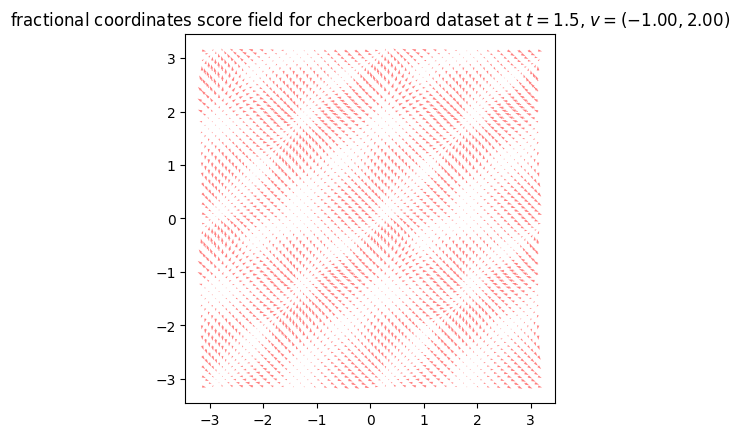

torch.Size([1])


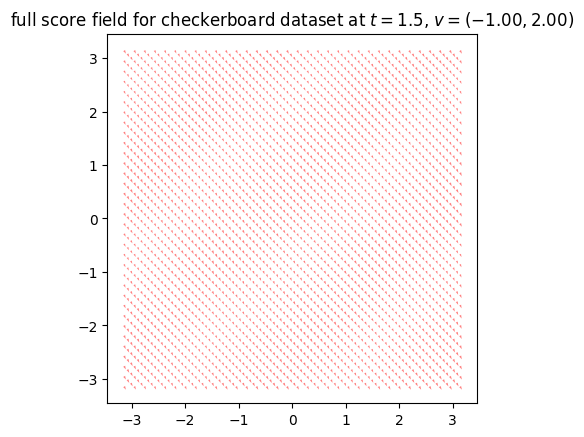

In [63]:



x_test = torch.linspace(-np.pi, np.pi, 100)
y_test = torch.linspace(-np.pi, np.pi, 100)
x_test, y_test = torch.meshgrid(x_test, y_test)
x_test = x_test.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
x_test = torch.cat([x_test, y_test], dim=-1)

x_test_batched = x_test[:,:]
print(x_test_batched.shape)
t_scalar = 1.5
v_scalar = torch.Tensor([[-1.0,2.0]])
print(v_scalar.shape)
print(x_test_batched.shape)
t_test = torch.full((10000, 1), t_scalar)   # (1, 10000, 1)
v_test = torch.ones_like(x_test_batched) * v_scalar

score = score_nn(x_test_batched, v_test, t_test)
print(score)
print(score.std(dim=1),score.mean(dim=0))
score = score.detach().cpu()
print(score.shape)
print(min(score[:,0]),max(score[:,0]))
print(min(score[:,1]),max(score[:,1]))

# shows every 3 points
score = score[::3,:]
x_test_batched = x_test_batched[::3,:]
t_test = t_test[::3,:]
v_test = v_test[::3,:]
print(t_test.shape)

fig,ax = plt.subplots()
# ax.scatter(x_test[:,0],x_test[:,1],c=x_test[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.quiver(x_test_batched[:,0],x_test_batched[:,1],score[:,0],score[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"fractional coordinates score field for checkerboard dataset at $t = {t_scalar}$, $v = ({v_scalar[0,0]:.2f}, {v_scalar[0,1]:.2f})$")
plt.show()

t_for_score = torch.Tensor([fixed_t])
print(t_for_score.shape)

score_v = (1- torch.exp(-t_test))/(1 + torch.exp(-t_test)) * score - v_test/ (model.sde.sigma_t(t_test)**2)

fig,ax = plt.subplots()
ax.quiver(x_test_batched[:,0],x_test_batched[:,1],score_v[:,0],score_v[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"full score field for checkerboard dataset at $t = {t_scalar}$, $v = ({v_scalar[0,0]:.2f}, {v_scalar[0,1]:.2f})$")
plt.show()


In [50]:
ft_list, vt_list, t_list = model.sample_backward(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    data_shape=(10000, 2), 
    total_time=2.0,
    tdm_score_fn=score_nn,
    sample_trajectory=True,
    n_steps = 1000
)






tensor([[ 2.0246,  1.3642],
        [ 2.0922,  0.8571],
        [ 2.3705, -2.4214],
        ...,
        [ 2.9430, -0.0410],
        [-1.1521,  2.3818],
        [-0.6995,  1.4450]], grad_fn=<Atan2Backward0>)
tensor([[ 2.0246,  1.3642],
        [ 2.0922,  0.8571],
        [ 2.3705, -2.4214],
        ...,
        [ 2.9430, -0.0410],
        [-1.1521,  2.3818],
        [-0.6995,  1.4450]], grad_fn=<Atan2Backward0>)
tensor([[-0.8719, -1.5544],
        [ 0.0344, -0.5256],
        [-0.4391,  1.1198],
        ...,
        [-0.2132,  1.0584],
        [ 2.1353, -0.5110],
        [-1.8578, -1.5733]], grad_fn=<AddBackward0>)
tensor(-3.1401, grad_fn=<UnbindBackward0>) tensor(3.1414, grad_fn=<UnbindBackward0>)
tensor(-3.1411, grad_fn=<UnbindBackward0>) tensor(3.1412, grad_fn=<UnbindBackward0>)
tensor([0.0020])


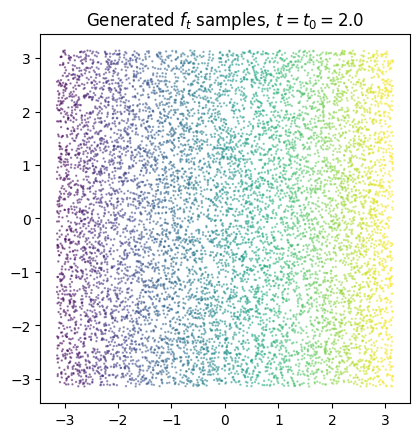

tensor([[ 1.2913, -2.6990],
        [ 1.3692,  0.8752],
        [-2.2471, -1.7086],
        ...,
        [-1.7724,  0.2879],
        [-2.4528, -1.9740],
        [ 1.7706,  2.9997]])
tensor([[ 0.0951,  0.0020],
        [-0.0043,  0.0937],
        [ 0.0074, -0.0133],
        ...,
        [-0.0749, -0.0106],
        [-0.0016,  0.0071],
        [-0.0230, -0.0779]])


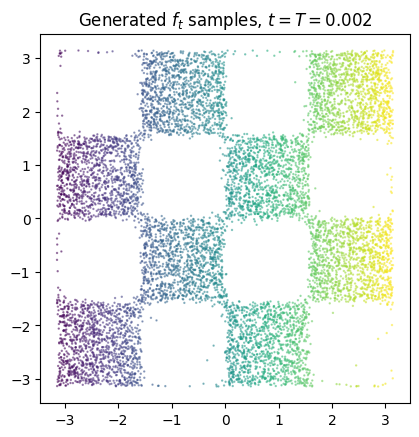

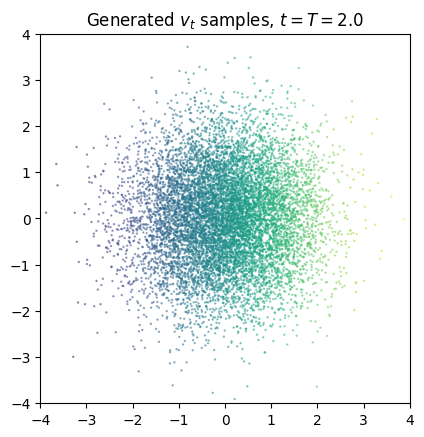

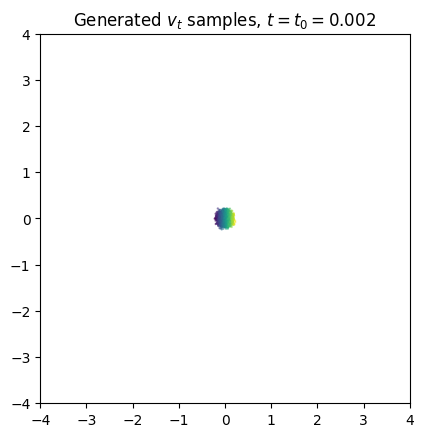

In [54]:
fT_init = ft_list[0]
vT_init = vt_list[0]

print(fT_init)

print(fT_init)
print(vT_init)
print(min(fT_init[:,0]),max(fT_init[:,0]))
print(min(fT_init[:,1]),max(fT_init[:,1]))
print(t_list[-1])

fT_init = fT_init.detach().cpu()
vT_init = vT_init.detach().cpu()
fig,ax = plt.subplots()
ax.scatter(fT_init[:,0],fT_init[:,1],c=fT_init[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Generated $f_t$ samples, $t = t_0 = {2.0}$")
plt.show()

fT_final = ft_list[-1].detach().cpu()
vT_final = vt_list[-1].detach().cpu()
print(fT_final)
print(vT_final)

fig,ax = plt.subplots()
ax.scatter(fT_final[:,0],fT_final[:,1],c=fT_final[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Generated $f_t$ samples, $t = T = {0.002}$")
plt.show()

fig,ax = plt.subplots()
ax.scatter(vT_init[:,0],vT_init[:,1],c=vT_init[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.set_title(f"Generated $v_t$ samples, $t = T = {2.0}$")
plt.show()

fig,ax = plt.subplots()
ax.scatter(vT_final[:,0],vT_final[:,1],c=vT_final[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.set_title("Generated $v_t$ samples, $t = t_0 = {0.002}$")
plt.show()





In [40]:
import torch
score_nn.eval()
device = "cpu"
# sanity: what does the network output for a fixed f, v across t?
with torch.no_grad():
    B = 256
    f_test = torch.zeros(B,  2, device=device)             # f = 0
    v_test = torch.randn(B, 2, device=device) * 0.1       # small v
    for t_val in [0.05, 0.5, 1.0, 1.5, 1.95]:
        t_test = torch.full((B, 1), t_val, device=device)
        pred = score_nn(f_test, v_test, t_test)
        # what should the target be?
        sigma_v = model.sde.sigma_t(torch.tensor(t_val))
        expected_v_term = -v_test / (sigma_v**2)   # the dominant term at small v
        print(f"t={t_val:.2f}: pred mean={pred.mean().item():+.3f} std={pred.std().item():.3f} "
              f"| expected -v/σ² mean={expected_v_term.mean().item():+.3f} std={expected_v_term.std().item():.3f}")


t=0.05: pred mean=+0.021 std=0.038 | expected -v/σ² mean=+0.040 std=1.077
t=0.50: pred mean=-0.060 std=0.122 | expected -v/σ² mean=+0.006 std=0.162
t=1.00: pred mean=+0.043 std=0.107 | expected -v/σ² mean=+0.004 std=0.119
t=1.50: pred mean=+0.020 std=0.037 | expected -v/σ² mean=+0.004 std=0.108
t=1.95: pred mean=+0.004 std=0.018 | expected -v/σ² mean=+0.004 std=0.105


In [41]:
score_nn.eval()
with torch.no_grad():
    B = 256
    # FIX f at different non-zero values, set v=0
    v_test = torch.zeros(B, 2)        # v = 0 to isolate WN term
    t_val = 0.5
    t_test = torch.full((B, 1), t_val)
    
    for f_val in [0.0, 1.0, 2.0, 3.0, -2.0]:
        f_test = torch.full((B, 2), f_val)
        pred = score_nn(f_test, v_test, t_test)
        print(f"f={f_val:+.1f}, v=0: pred mean={pred.mean(dim=0).squeeze().tolist()}, std={pred.std():.3f}")

f=+0.0, v=0: pred mean=[-0.08600262552499771, -0.037603385746479034], std=0.024
f=+1.0, v=0: pred mean=[-0.0007472224533557892, -0.009854043833911419], std=0.005
f=+2.0, v=0: pred mean=[0.019569944590330124, -0.014455602504312992], std=0.017
f=+3.0, v=0: pred mean=[0.16284754872322083, 0.22394753992557526], std=0.031
f=-2.0, v=0: pred mean=[-0.021474013105034828, 0.01201131846755743], std=0.017


In [42]:
score_nn.eval()
with torch.no_grad():
    B = 256
    f_test = torch.zeros(B, 2)              # f = 0
    t_test = torch.full((B, 1), 0.5)
    for v_val in [-1.0, -0.5, 0.0, 0.5, 1.0]:
        v_test = torch.full((B, 2), v_val)
        pred = score_nn(f_test, v_test, t_test)
        sig_v = model.sde.sigma_t(torch.tensor(0.5))
        expected = -v_val / (sig_v**2).item()
        print(f"v={v_val:+.2f}: pred[0]={pred[0,0].item():+.3f} pred[1]={pred[0,1].item():+.3f} | -v/σ²={expected:+.3f}")

v=-1.00: pred[0]=-0.078 pred[1]=-0.147 | -v/σ²=+1.582
v=-0.50: pred[0]=-0.272 pred[1]=-0.247 | -v/σ²=+0.791
v=+0.00: pred[0]=-0.086 pred[1]=-0.038 | -v/σ²=-0.000
v=+0.50: pred[0]=+0.189 pred[1]=+0.243 | -v/σ²=-0.791
v=+1.00: pred[0]=+0.097 pred[1]=+0.090 | -v/σ²=-1.582


In [43]:
# ===== DIAGNOSTIC: Can a freshly initialized model vary its output? =====
import torch
import torch.nn as nn

# Create a FRESH model (not loaded from checkpoint)
from src.scoreNN import TDM_SimpleScoreMLP

fresh_model = TDM_SimpleScoreMLP(
    dim=2, x_lifting_dim=64, time_embedding_half_dim=32,
    hidden_dim=[512, 512], output_dim=2, total_time=2.0,
    with_sincos_position=True, only_sincos_position=True
)

# Test 1: Does a FRESH model give different outputs for different inputs?
fresh_model.eval()
with torch.no_grad():
    for f_val in [0.0, 1.0, 2.0, -2.0]:
        f = torch.full((64, 2), f_val)
        v = torch.zeros(64, 2)
        t = torch.full((64, 1), 0.5)
        pred = fresh_model(f, v, t)
        print(f"FRESH f={f_val:+.1f}: pred={pred[0].tolist()}")

# Test 2: Overfit one batch
from src.diffusion import TDMDiffusion
from src.data import Checkerboard_Dataset, TorusLieWrapper, AngleTorusWrapper

diffusion = TDMDiffusion(dim=2, integrator_type="Euler", simplified_param=True)
ds = AngleTorusWrapper(TorusLieWrapper(Checkerboard_Dataset(num_rows=4, dataset_size=512)))
loader = torch.utils.data.DataLoader(ds, batch_size=512)
f0 = next(iter(loader)).float()

(vt, ft), target, ts = diffusion.sample_forward(f0=f0, total_time=2.0, return_time=True)


print(f"\ntarget stats: mean={target.mean():.3f}, std={target.std():.3f}, absmax={target.abs().max():.3f}")
print(f"max of ft: {ft.max()}, min of ft: {ft.min()}")
print(f"ft stats: mean={ft.mean():.3f}, std={ft.std():.3f}")
print(f"vt stats: mean={vt.mean():.3f}, std={vt.std():.3f}")
print(f"ts range: [{ts.min():.3f}, {ts.max():.3f}]")

# Now overfit this SINGLE BATCH
overfit_model = TDM_SimpleScoreMLP(
    dim=2, x_lifting_dim=64, time_embedding_half_dim=32,
    hidden_dim=[512, 512], output_dim=2, total_time=2.0,
    with_sincos_position=True, only_sincos_position=True
)
optimizer = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)

overfit_model.train()
for step in range(3001):
    pred = overfit_model(ft, vt, ts)
    loss = nn.functional.mse_loss(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 500 == 0:
        print(f"step {step}: loss={loss.item():.6f}")

# After overfitting, check if output varies
overfit_model.eval()
with torch.no_grad():
    for f_val in [0.0, 1.0, 2.0, -2.0, 2.0 + 2*torch.pi, 2.0 - 2*torch.pi]:
        f = torch.full((64, 2), f_val)
        v = torch.zeros(64, 2)
        t = torch.full((64, 1), 0.5)
        pred = overfit_model(f, v, t)
        print(f"OVERFIT f={f_val:+.1f}: pred={pred[0].tolist()}")

FRESH f=+0.0: pred=[0.11261110007762909, -0.08592242002487183]
FRESH f=+1.0: pred=[0.06287319958209991, -0.08483205735683441]
FRESH f=+2.0: pred=[0.03500660881400108, -0.12604176998138428]
FRESH f=-2.0: pred=[0.13415920734405518, -0.16126060485839844]

target stats: mean=0.015, std=0.996, absmax=3.961
max of ft: 3.1382908821105957, min of ft: -3.1327056884765625
ft stats: mean=-0.056, std=1.838
vt stats: mean=-0.001, std=0.881
ts range: [0.015, 1.999]
step 0: loss=1.012617
step 500: loss=0.036476
step 1000: loss=0.001484
step 1500: loss=0.004621
step 2000: loss=0.000270
step 2500: loss=0.001180
step 3000: loss=0.004228
OVERFIT f=+0.0: pred=[-0.03147941827774048, -1.1276535987854004]
OVERFIT f=+1.0: pred=[-0.929094135761261, 0.12168285250663757]
OVERFIT f=+2.0: pred=[0.39524024724960327, -1.126025676727295]
OVERFIT f=-2.0: pred=[-0.10770481824874878, -0.3439442217350006]
OVERFIT f=+8.3: pred=[0.3952389359474182, -1.1260273456573486]
OVERFIT f=-4.3: pred=[0.3952389359474182, -1.126027345